In [314]:
import pandas as pd  #  bib pour l'analyse de data frame
import seaborn as sns # pour la visialisation les graphe 
import matplotlib.pyplot as plt # pour la visialisation les graphe 

# Analyse du dataset de santé

In [315]:
# importation de data
df=sns.load_dataset('healthexp')
df.head(14)

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
5,1971,Canada,313.391,72.8
6,1971,Germany,298.251,70.8
7,1971,Great Britain,134.172,71.9
8,1971,Japan,163.854,72.9
9,1971,USA,357.988,71.2


In [316]:
df.shape

(274, 4)

In [317]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    str    
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), str(1)
memory usage: 8.7 KB


In [318]:
# donner des statisques rapides
df.describe()

,Year,Spending_USD,Life_Expectancy
count,274.000000,274.000000,274.000000
mean,1996.992701,2789.338905,77.909489
std,14.180933,2194.939785,3.276263
min,1970.000000,123.993000,70.600000
25%,1985.250000,1038.357000,75.525000
50%,1998.000000,2295.578000,78.100000
75%,2009.000000,4055.610000,80.575000
max,2020.000000,11859.179000,84.700000


In [319]:
#pour voir les valeur monque 
df.isnull().sum()

Year               0
Country            0
Spending_USD       0
Life_Expectancy    0
dtype: int64

Analysez la variable "Country"

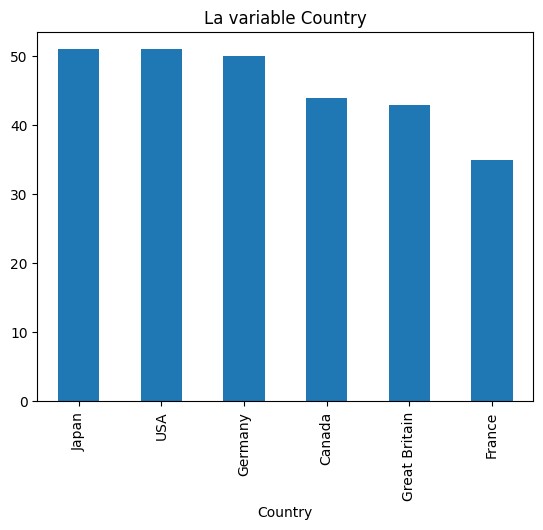

In [320]:
df["Country"].value_counts()
df["Country"].value_counts().plot(kind="bar")
plt.title("La variable Country")
plt.show()

On étudie ici le nombre de pays. On observe que le Japon, les États-Unis et l'Allemagne ont chacun une effectif d'environ 50, tandis que le Canada, la France et la Grande-Bretagne présentent des effectifs 40.


Analysez la variable "Spending_USD"

Text(0.5, 1.0, 'La variable Spending_USD')

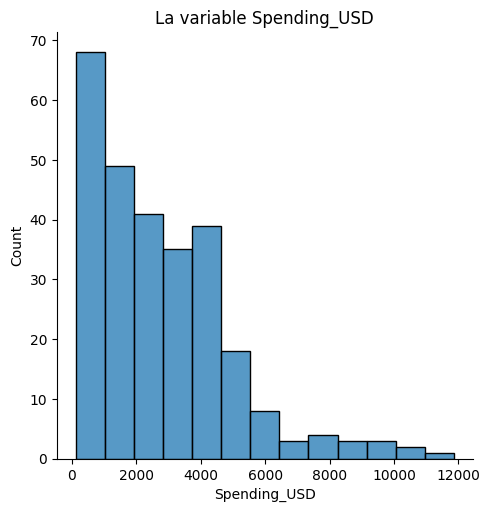

In [321]:
sns.displot(data=df,x="Spending_USD")
#sns.boxplot(data=df,x="Spending_USD")
plt.title("La variable Spending_USD")

À travers ce graphique, on remarque que la variable dépenses_usd atteint des valeurs élevées dans l'intervalle de 0 à 2000, puis elle diminue progressivement de façon régulière.

 1- Faites de même pour la variable "Life_Expectancy"

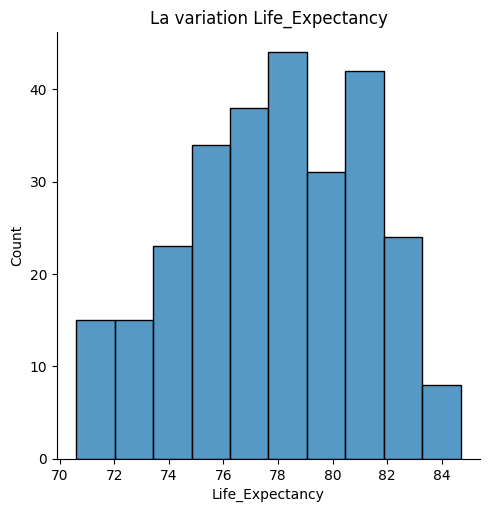

In [322]:
#sns.boxplot(data=df,x="Life_Expectancy")
sns.displot(data=df,x="Life_Expectancy")
plt.title("La variation Life_Expectancy")
plt.show()
#df["Life_Expectancy"].value_counts()

2-Observez l'évolution de la durée de vie à travers le temps

Text(0.5, 1.0, 'évolution de la durée de vie à travers le temps')

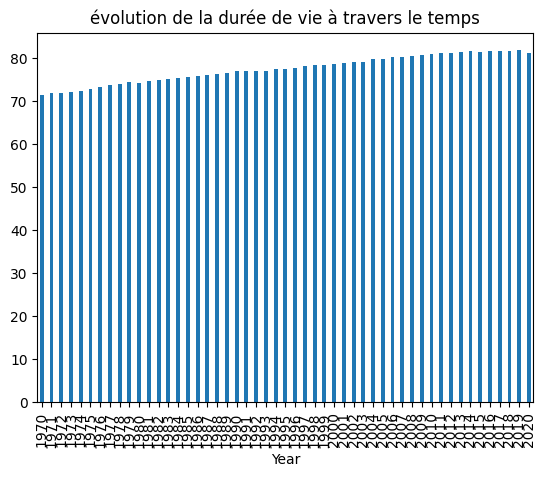

In [323]:
#sns.boxplot(data=df,x="Year",y="Life_Expectancy")
df.groupby("Year")["Life_Expectancy"].mean().plot(kind="bar", width=0.4)
plt.title("évolution de la durée de vie à travers le temps")
#plt.xticks(rotation=45)  # incliner les années
#plt.tight_layout()       # ajuster les marges

<Axes: xlabel='Year', ylabel='Life_Expectancy'>

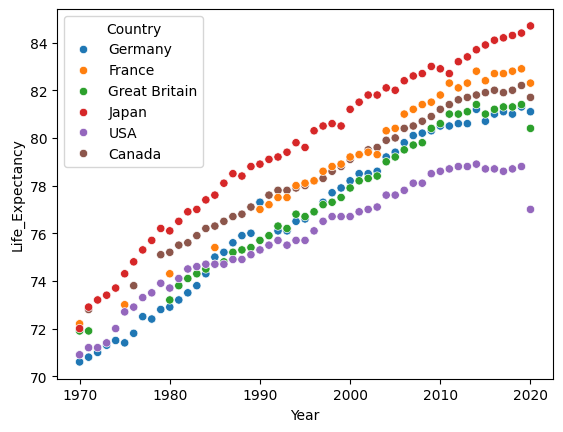

In [324]:
sns.scatterplot(data=df,x="Year",y="Life_Expectancy",hue="Country")
#sns.displot(data=df,x="Year",y="Life_Expectancy",hue="Country")

1-Observez l'évolution des dépenses en santé de l'Allemagne et de la Grande Bretagne à travers le temps.


<Axes: xlabel='Spending_USD'>

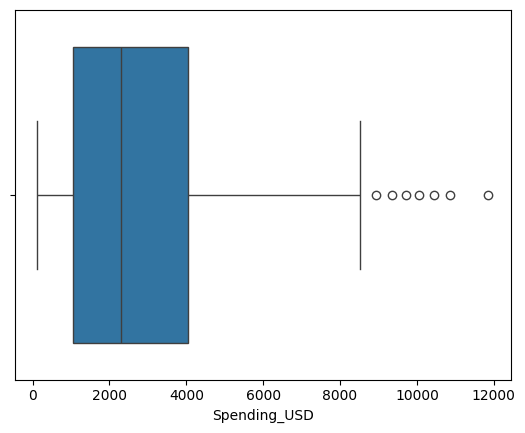

In [325]:
sns.boxplot(data=df,x="Spending_USD")

1-Observez l'évolution des dépenses en santé de l'Allemagne et de la Grande Bretagne à travers le temps

In [326]:
df.query("`Country`=='Germany' | `Country`=='Great Britain'")

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
2,1970,Great Britain,123.993,71.9
6,1971,Germany,298.251,70.8
7,1971,Great Britain,134.172,71.9
10,1972,Germany,337.364,71.0
...,...,...,...,...
259,2018,Great Britain,4189.708,81.3
263,2019,Germany,6407.928,81.3
265,2019,Great Britain,4385.463,81.4
269,2020,Germany,6938.983,81.1


<Axes: xlabel='Year', ylabel='Spending_USD'>

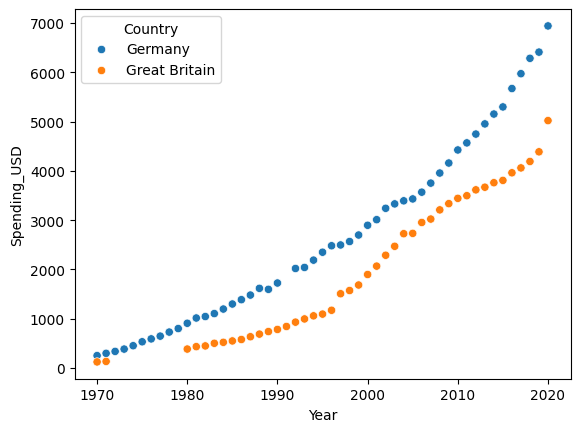

In [327]:
sns.scatterplot(data=df.query("`Country`=='Germany' | `Country`=='Great Britain'"),x="Year",y="Spending_USD",hue="Country")

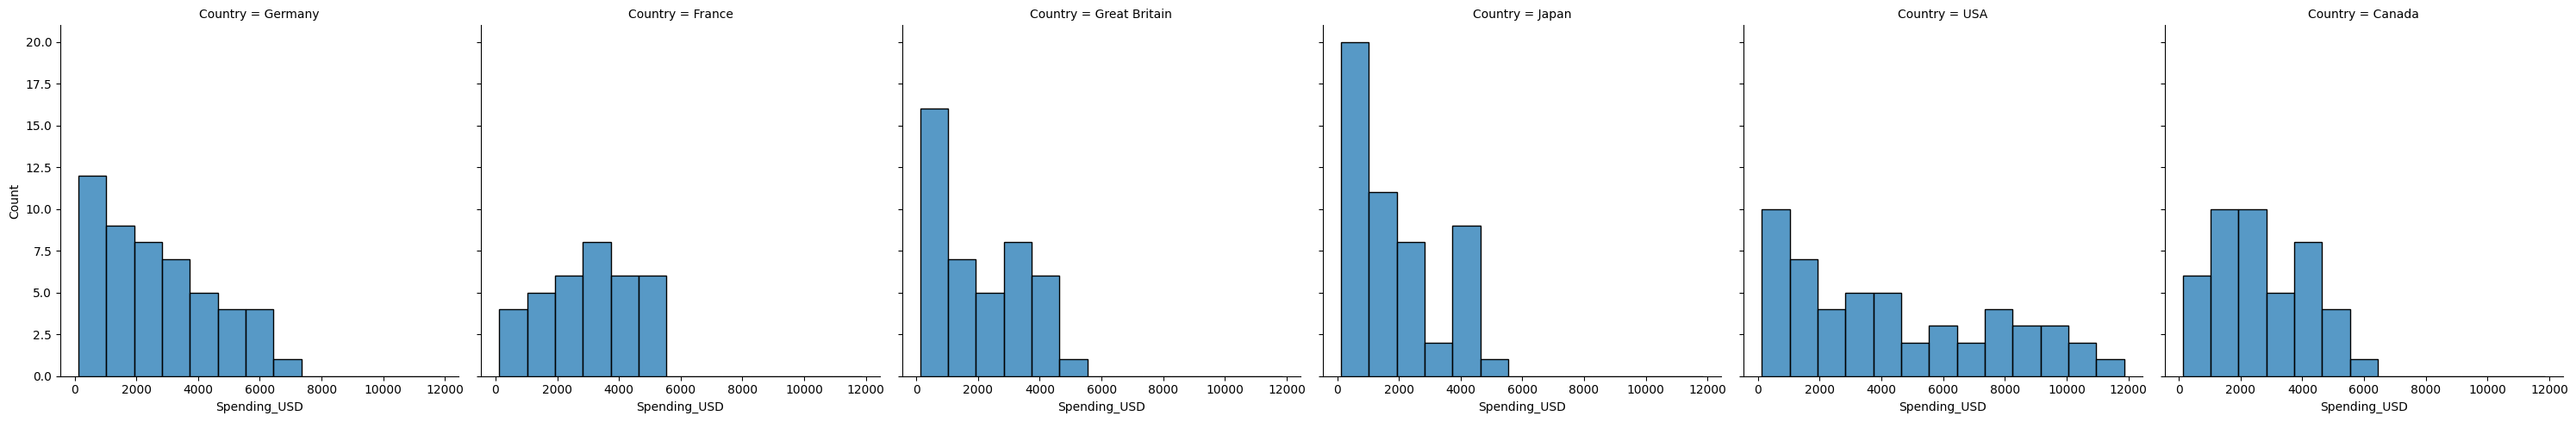

In [328]:
sns.displot(data=df,x="Spending_USD",col="Country")

2-Observez l'histogramme, la boxplot, et les statistiques de "Life_Expectancy" propre à chaque pays.

<Axes: xlabel='Country', ylabel='Life_Expectancy'>

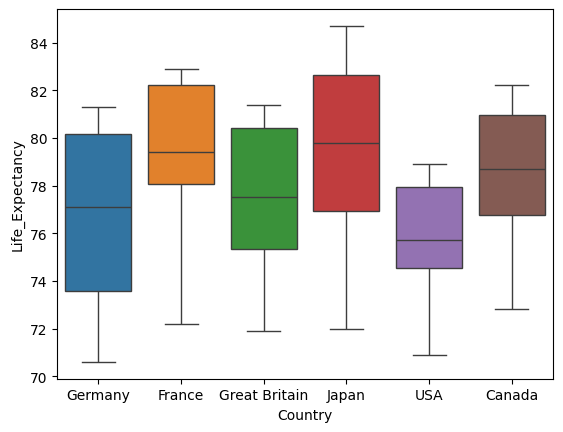

In [329]:
sns.boxplot(data=df,x="Country",y="Life_Expectancy",hue="Country")

3-Observez la relation entre la durée de vie et les dépenses dans la santé, aux États-Unis, de 2000 à 2020

In [330]:
#sns.scatterplot(data=df.query("`Country` == 'USA' & `Year`>=2000"),x="Spending_USD",y="Life_Expectancy")
#for index, row in df.query("`Country` == 'USA' & `Year`>=2000").iterrows():
#   plt.text(row["Spending_USD"],row["Life_Expectancy"])+0.1,str(row["Year"]),color='black',ha='center')
#usa = df[(df["Country"] == "USA") & (df["Year"].between(2000, 2020))]
#sns.scatterplot(data=usa,x="Spending_USD",y="Life_Expectancy")
#usa = df.query("Country == 'USA' and 2000 <= Year <= 2020")
#sns.scatterplot(data=usa,x="Spending_USD",y="Life_Expectancy")

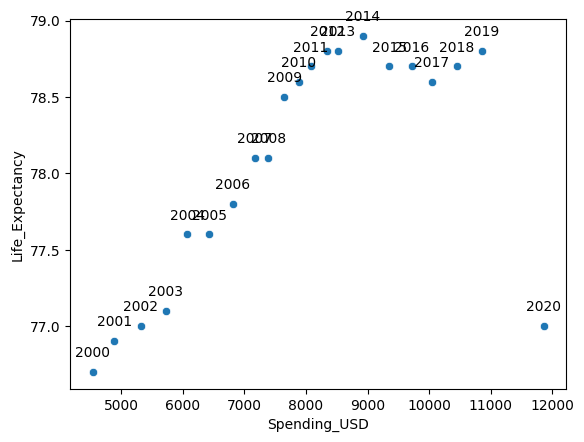

In [331]:
#Crée le scratter plot
sns.scatterplot(data=df.query("`Country` == 'USA' & `Year`>=2000"),x="Spending_USD",y="Life_Expectancy")
# Ajouter les années au-dessus de chaque point
for index, row in df.query("`Country` == 'USA' & `Year`>=2000").iterrows():
   plt.text(row["Spending_USD"],row["Life_Expectancy"] + 0.1, str(row["Year"]),color='black',ha='center')
#Afficher le graphique
plt.show()

PearsonRResult(statistic=np.float64(0.6210674528998252), pvalue=np.float64(0.0026581544805799064))

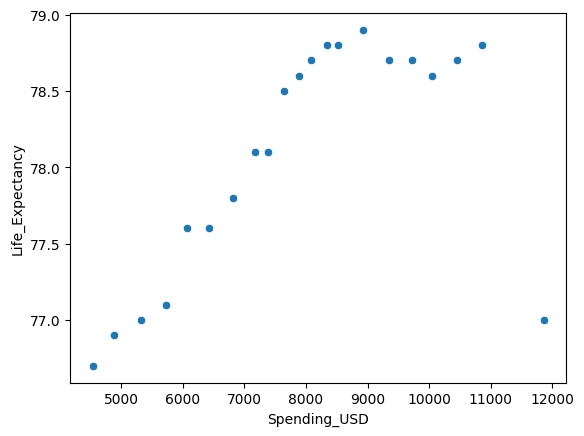

In [332]:
from scipy.stats import pearsonr
df_temp= df.query("`Country` == 'USA' & `Year`>=2000")
sns.scatterplot(data=df_temp,x="Spending_USD",y="Life_Expectancy")
pearsonr(df_temp["Spending_USD"],df_temp["Life_Expectancy"])


4- Il y a une valeur abérante tant tout cela. Laquelle? Pourquoi?
oui il existe plus valeur abérante : dans le graphe de

# Phase 3 – Application – Dataset MPG
 Objectif : Réinvestir les concepts statistiques dans un nouveau contexte métier, avec plus d’autonomie.

1- Quelles sont les variables discrètes et continues de ce dataset ?

In [333]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy.stats import pearsonr
import scipy.stats
import scipy.optimize

** mpg (Miles Per Gallon)
→ consommation de carburant :
Plus la valeur est élevée , plus la voiture est économique.
** accélération
Plus la valeur est faible , plus la voiture est rapide.
** cylindres
→ nombre de cylindres (ex : 4, 6, 8) :
Plus il y en a, plus le moteur est puissant (souvent)
** déplacement
taille du moteur (en pouces cubes):
Grande valeur = moteur plus gros
** horsepower
→ puissance du moteur :
Plus élevé = voiture plus puissante
** poids
→ poids de la voiture
Voitures lourdes → consomment plus


In [334]:
df = sns.load_dataset('mpg')
df.head(20)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [335]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [336]:
df.shape

(398, 9)

In [337]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [338]:
df.duplicated().sum()

np.int64(0)

In [339]:
df = df.dropna(subset=['horsepower'])

In [340]:
df.shape

(392, 9)

Travail demandé :
1- Quelles sont les variables discrètes et continues de ce dataset ?

les variables discrètes : model_year - origin - name - cylinders 


les variable continues : mpg - displacement - horsepower - weight

Analysez la variable mpg
   1-Quelle est la moyenne ? Que représente-t-elle réellement ? (soyez précis)

In [341]:
moyenne_mpg = df["mpg"].mean()
moyenne_mpg 

np.float64(23.445918367346938)

Le moyenne de mpg est : 23.44   ** voitures anciennes puissantes → 10 à 15 mpg
 ** voitures économiques → 30 à 40 mpg   ** donc : 23.44 est une valeur intermédiaire

2-Tracez les 2 graphiques pertinents pour cette variable :

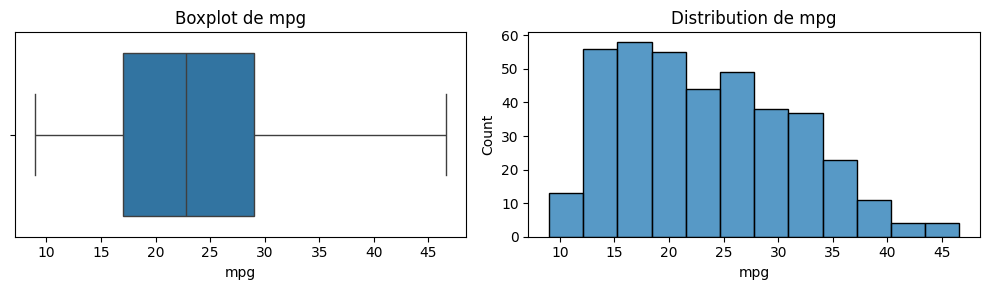

In [342]:
fig, ax = plt.subplots(1, 2, figsize=(10,3))

sns.boxplot(data=df, x="mpg", ax=ax[0])
ax[0].set_title("Boxplot de mpg")

sns.histplot(data=df, x="mpg", ax=ax[1])
ax[1].set_title("Distribution de mpg")

plt.tight_layout()# agrandir les figure
plt.show()

3- Analysez la variable cylinders

In [ ]:
df ["cylinders"].value_counts()

cylinders
4    199
8    103
6     83
3      4
5      3
Name: count, dtype: int64

Text(0.5, 1.0, 'Analyse de la distribution du nombre de cylindres des véhicules')

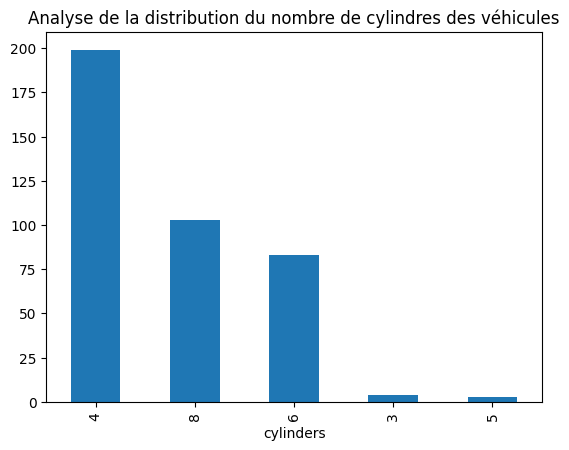

In [351]:
df["cylinders"].value_counts().plot(kind="bar")
plt.title("Analyse de la distribution du nombre de cylindres des véhicules")

4- Analysez la variable origin


Text(0.5, 1.0, 'Analyse de la distribution du nombre de origin')

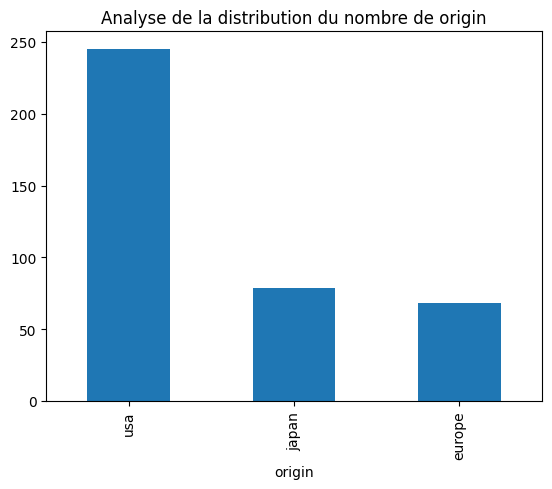

In [354]:
df["origin"].value_counts().plot(kind="bar")
plt.title("Analyse de la distribution du nombre de origin")

5- Observez l'évolution de la consommation des voitures (mpg) par rapport au nombre de chevaux (horsepower)

Text(0.5, 1.0, 'évolution de la consommation des voitures (mpg) par rapport au nombre de (horsepower)')

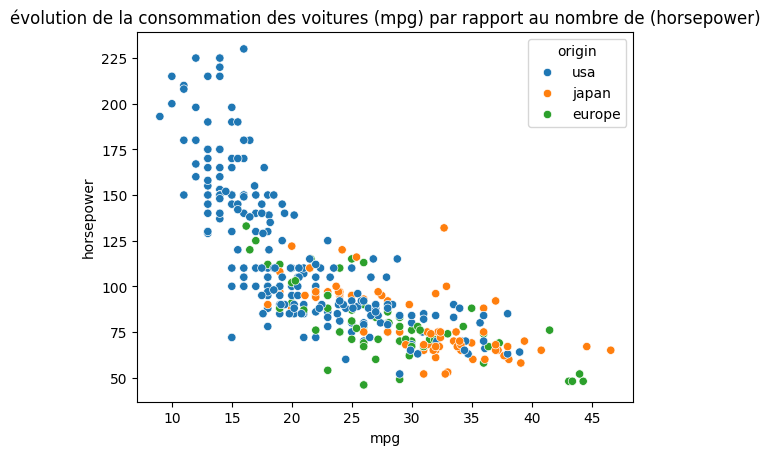

In [363]:
sns.scatterplot(data=df,x="mpg",y="horsepower",hue="origin")
plt.title("évolution de la consommation des voitures (mpg) par rapport au nombre de (horsepower)")

Text(0.5, 1.0, 'évolution de la consommation des voitures (mpg) par rapport au nombre de (horsepower)')

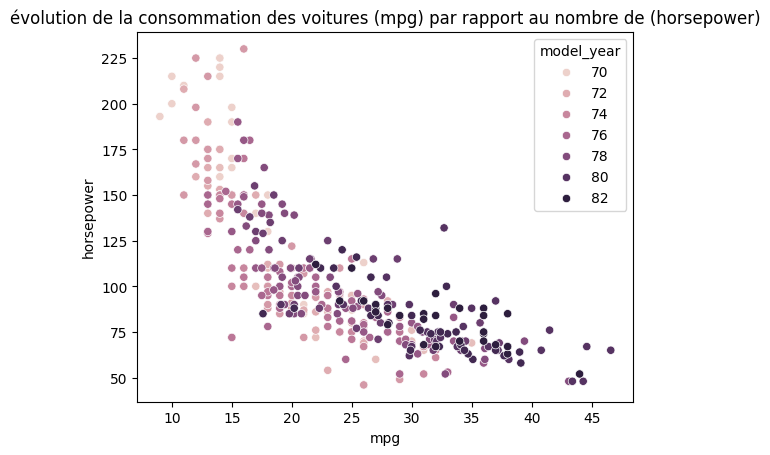

In [364]:
sns.scatterplot(data=df,x="mpg",y="horsepower",hue="model_year")
plt.title("évolution de la consommation des voitures (mpg) par rapport au nombre de (horsepower)")

on vous voir que au cour de l'année le horsepower 

6- Observez l'évolution du poids moyen des voitures américaines de l'année 70 jusqu'à l'année 82

Text(0.5, 1.0, "L'évolution du poids moyen des voitures américaines de l'année 70 jusqu'à l'année 82")

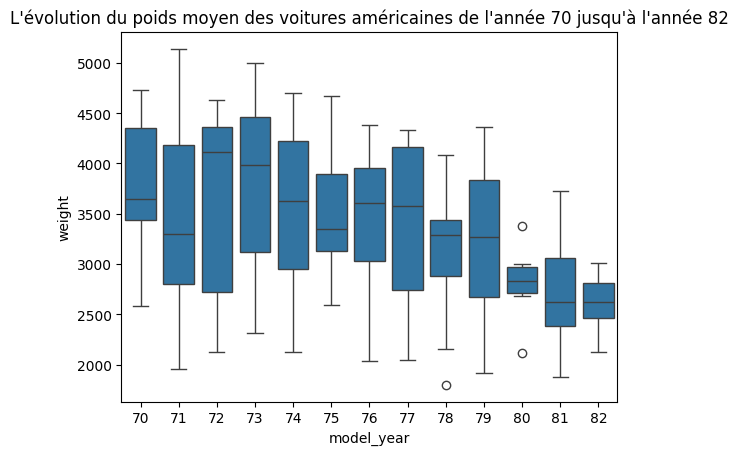

In [379]:
#df.groupby(""origin" =='usa'")["weight"].mean().plot(kind="bar")
sns.boxplot(data=df.query("`origin` == 'usa' "),x="model_year",y="weight")
plt.title("L'évolution du poids moyen des voitures américaines de l'année 70 jusqu'à l'année 82")

7-Analysez la relation entre le nombre de cylindres et l'année du modèle.


Text(0.5, 1.0, "La relation entre le nombre de cylindres et l'année du modèle")

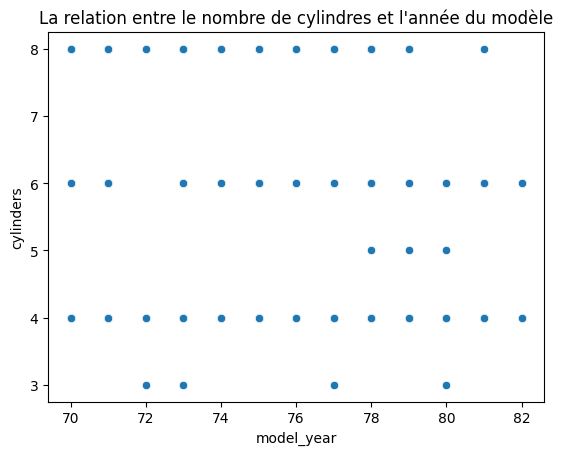

In [383]:
sns.scatterplot(data=df,x="model_year",y="cylinders")
plt.title("La relation entre le nombre de cylindres et l'année du modèle")

8-Analysez la relation entre le nombre de cylindres et l'origine.

Text(0.5, 1.0, "La relation entre le nombre de cylindres et l'origine")

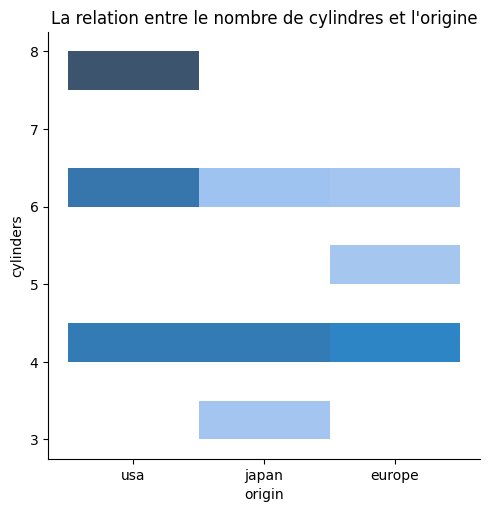

In [386]:
sns.displot(data=df,x="origin",y="cylinders")
plt.title("La relation entre le nombre de cylindres et l'origine")

9-Quelle est l'accélération moyenne des voitures des différents pays ?

<Axes: xlabel='origin', ylabel='acceleration'>

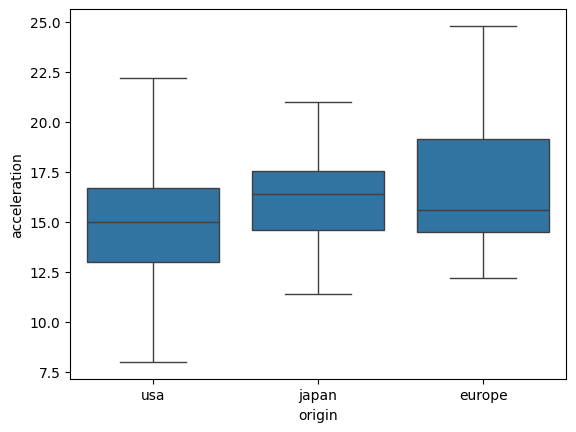

In [388]:
sns.boxplot(data=df,x="origin",y="acceleration")